In [47]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from pydantic import BaseModel
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [48]:
load_dotenv()

True

In [49]:
llm = ChatGroq(model="llama-3.1-8b-instant")

In [50]:
taskCategory = Literal["summarizer", "email_writer", "planner", "bullet_point_maker"]

class WorkflowState(TypedDict):
    userInput: str
    taskCategory: taskCategory
    output: str

class TaskOut(BaseModel):
    taskCategory: taskCategory

In [51]:
def taskClassifier(state:WorkflowState) -> WorkflowState:
    prompt = f"""You are a helpful assistant that categorizes user requests into one of the following categories: summarizer, email_writer, planner, bullet_point_maker. Here is the user request: {state['userInput']}"""
    classifier = llm.with_structured_output(TaskOut)
    response = classifier.invoke(prompt)
    state['taskCategory'] = response.taskCategory
    return state

In [ ]:
def summarizer(state:WorkflowState) -> WorkflowState:
    prompt = f"""You are a helpful assistant that summarizes user requests. Here is the user request: {state['userInput']}"""
    response = llm.invoke(prompt)
    state["output"] = response.content
    return state

def email_writer(state:WorkflowState) -> WorkflowState:
    prompt = f"""You are a helpful assistant that writes emails based on user requests. Here is the user request: {state['userInput']}"""
    response = llm.invoke(prompt)
    state["output"] = response.content
    return state

def planner(state:WorkflowState) -> WorkflowState:
    prompt = f"""You are a helpful assistant that creates plans based on user requests. Here is the user request: {state['userInput']}"""
    response = llm.invoke(prompt)
    state["output"] = response.content
    return state

def bullet_point_maker(state:WorkflowState) -> WorkflowState:
    prompt = f"""You are a helpful assistant that creates bullet points based on user requests. Here is the user request: {state['userInput']}"""
    response = llm.invoke(prompt)
    state["output"] = response.content
    return state

def routeTask(state: WorkflowState):
    if state["taskCategory"] == "summarizer":
        return "summarizer"
    elif state["taskCategory"] == "email_writer":
        return "email_writer"
    elif state["taskCategory"] == "planner":
        return "planner"
    elif state["taskCategory"] == "bullet_point_maker":
        return "bullet_point_maker"
    else:
        raise ValueError(f"Unknown taskCategory: {state['taskCategory']}")

In [53]:
graph = StateGraph(WorkflowState)

graph.add_node("taskClassifier", taskClassifier)
graph.add_node("summarizer", summarizer)
graph.add_node("email_writer", email_writer)
graph.add_node("planner", planner)
graph.add_node("bullet_point_maker", bullet_point_maker)

graph.add_edge(START, "taskClassifier")
graph.add_conditional_edges("taskClassifier", routeTask)
graph.add_edge("summarizer", END)
graph.add_edge("email_writer", END)
graph.add_edge("planner", END)
graph.add_edge("bullet_point_maker", END)

workflow = graph.compile()

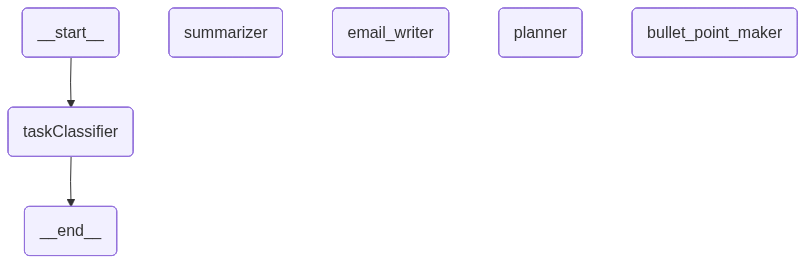

In [59]:


from IPython.display import Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))

In [60]:
test_state = {
    "userInput": "3 must have daily routines",
    "taskCategory": "",
    "output": ""
}

result = taskClassifier(test_state)
print(result['taskCategory'])

planner


In [61]:
result = workflow.invoke(test_state)

In [62]:
print(result['output'].content)

Based on general wellness and productivity guidelines, I've created three must-have daily routines that you may find helpful:

**Routine 1: Morning Routine (15-30 minutes)**

1. **Wake-up time**: Set your alarm 15-30 minutes earlier than usual.
2. **Stretching or exercise**: Begin with some light stretching or a quick 5-10 minute workout to get your blood flowing.
3. **Mindfulness or meditation**: Take a few minutes to practice mindfulness, deep breathing, or meditation to clear your mind and set intentions for the day.
4. **Hydration and nutrition**: Drink a glass of water, and consider having a healthy breakfast to fuel your body for the day ahead.

**Routine 2: Mid-Day Routine (15-30 minutes)**

1. **Take a break**: Schedule a short break in the middle of your workday to recharge and refocus.
2. **Stretching or movement**: Take a short walk, do a few jumping jacks, or stretch your muscles to increase blood flow and reduce fatigue.
3. **Gratitude practice**: Reflect on the things you